In [ ]:
# Terrain Analysis from LIDAR-derived MDT 50cm Portugal proximo Portalegre

In [ ]:
# Bibliotecas - Via Colab
!pip install rasterio
!pip install matplotlib
!pip install numpy
!pip install scipy
!pip install Pillow

In [ ]:
# Importando
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
from PIL import Image

In [ ]:
# Abrindo MDT
dem_path = "/content/MDT-50cm-263263-04-2024_v01.tif"

with rasterio.open(dem_path) as src:

    dem = src.read(1)

    profile = src.profile

    transform = src.transform

    crs = src.crs

print(profile)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -999.0, 'width': 2000, 'height': 2000, 'count': 1, 'crs': CRS.from_wkt('PROJCS["ETRS89 / Portugal TM06",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4258"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",39.6682583333333],PARAMETER["central_meridian",-8.13310833333333],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3763"]]'), 'transform': Affine(0.5, 0.0, 63000.0,
       0.0, -0.5, -37000.0), 'blockxsize': 2000, 'blockysize': 1, 'tiled': False, 'interleave': 'band'}


In [ ]:
# Estatisticas
print("Altitude mínima:", np.nanmin(dem))

print("Altitude máxima:", np.nanmax(dem))

print("Altitude média:", np.nanmean(dem))

Altitude mínima: 538.828
Altitude máxima: 733.396
Altitude média: 650.0551


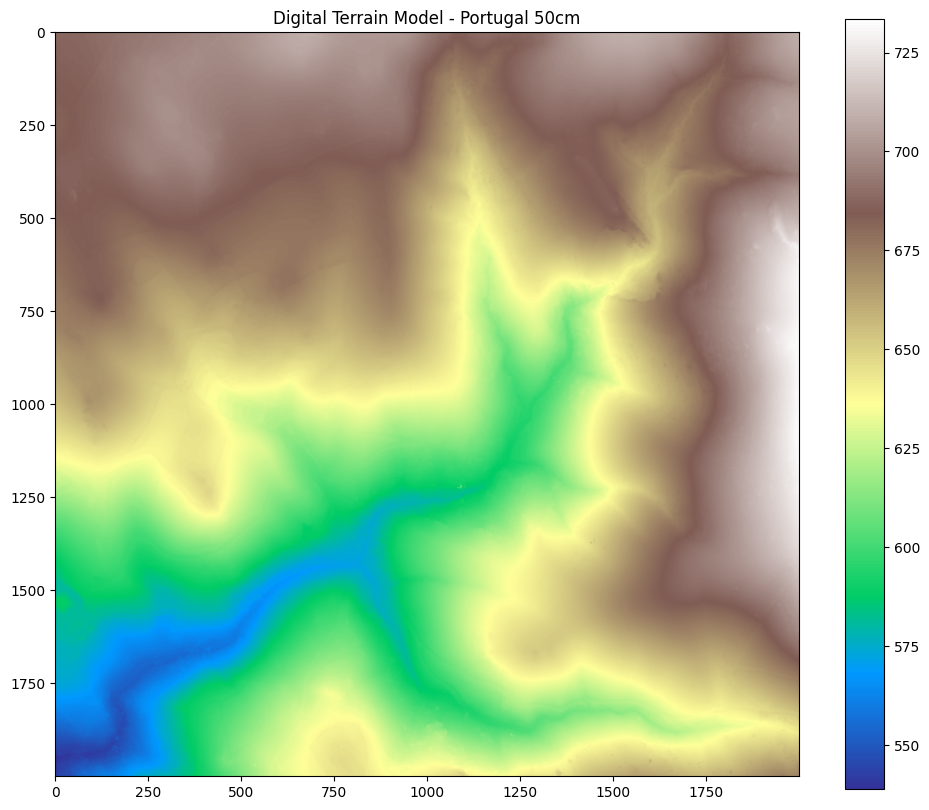

In [ ]:
# Visualização
plt.figure(figsize=(12,10))

plt.imshow(dem,cmap="terrain")

plt.colorbar()

plt.title("Digital Terrain Model - Portugal 50cm")
plt.savefig("DTM.png")
plt.show()

In [ ]:
# Hilshade
x, y = np.gradient(dem)

slope = np.pi/2 - np.arctan(np.sqrt(x*x+y*y))

aspect = np.arctan2(-x,y)

az = np.radians(315)

alt = np.radians(45)

hillshade = (

np.sin(alt)

*

np.sin(slope)

+

np.cos(alt)

*

np.cos(slope)

*

np.cos(az-aspect)

)

Text(0.5, 1.0, 'Digital Terrain Model - Portugal 50cm')

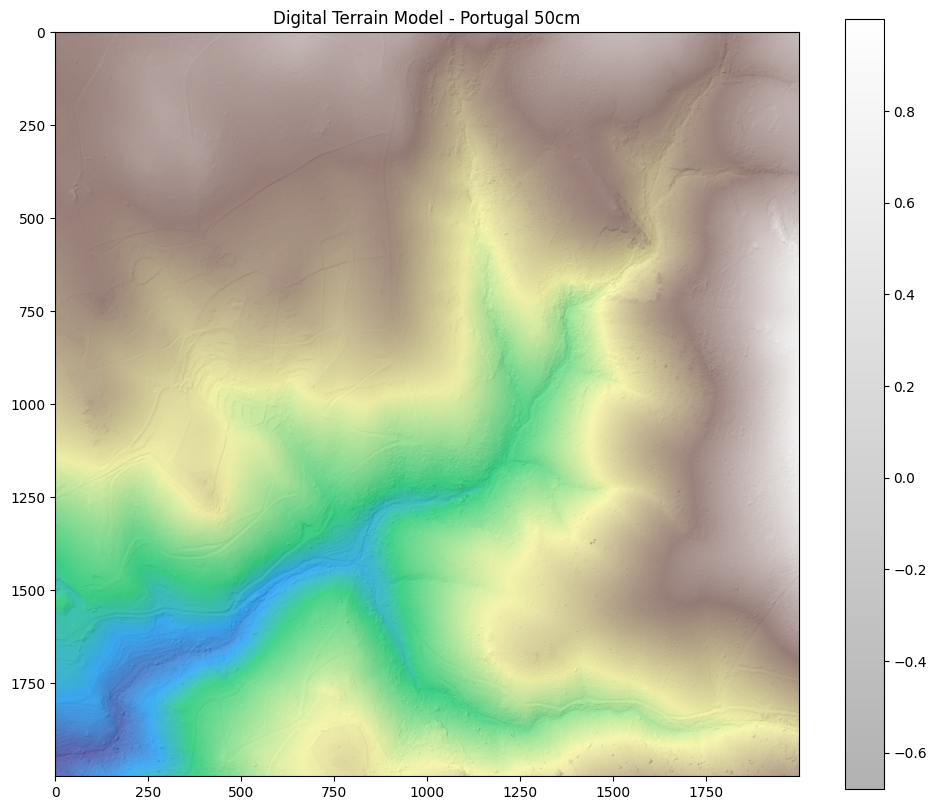

In [ ]:
# Hilshade e DTM plotados junto
plt.figure(figsize=(12,10))

plt.imshow(dem,cmap="terrain")

plt.imshow(hillshade,cmap="gray",alpha=0.3)

plt.colorbar()
plt.savefig("DTM_Hillshade.png")
plt.title("Digital Terrain Model - Portugal 50cm")

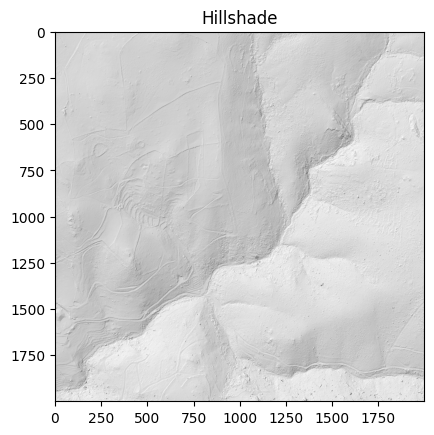

In [ ]:
plt.imshow(hillshade, cmap='gray')
plt.title("Hillshade")
plt.savefig("Hillshade.png")
plt.show()

In [ ]:
# Declividade
dx,dy=np.gradient(dem)

slope=np.degrees(

np.arctan(

np.sqrt(dx**2+dy**2)

)

)

In [ ]:
# Aspect
aspect=np.degrees(

np.arctan2(

dy,

-dx

)

)

Text(0.5, 1.0, 'Slope (degrees)')

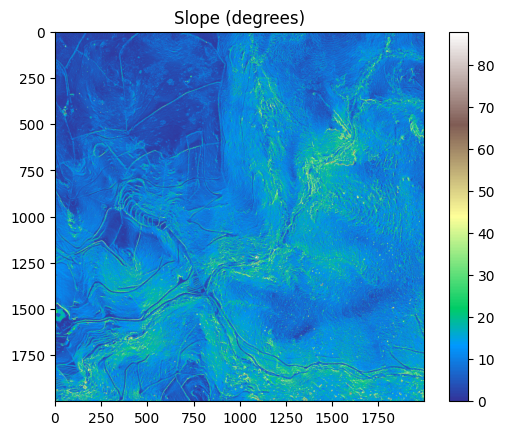

In [ ]:
# Visualização
plt.imshow(

slope,

cmap="terrain"   # 'inferno','terrain','gist_rainbow','turbo'

)

plt.colorbar()
plt.savefig("Slope.png")
plt.title("Slope (degrees)")

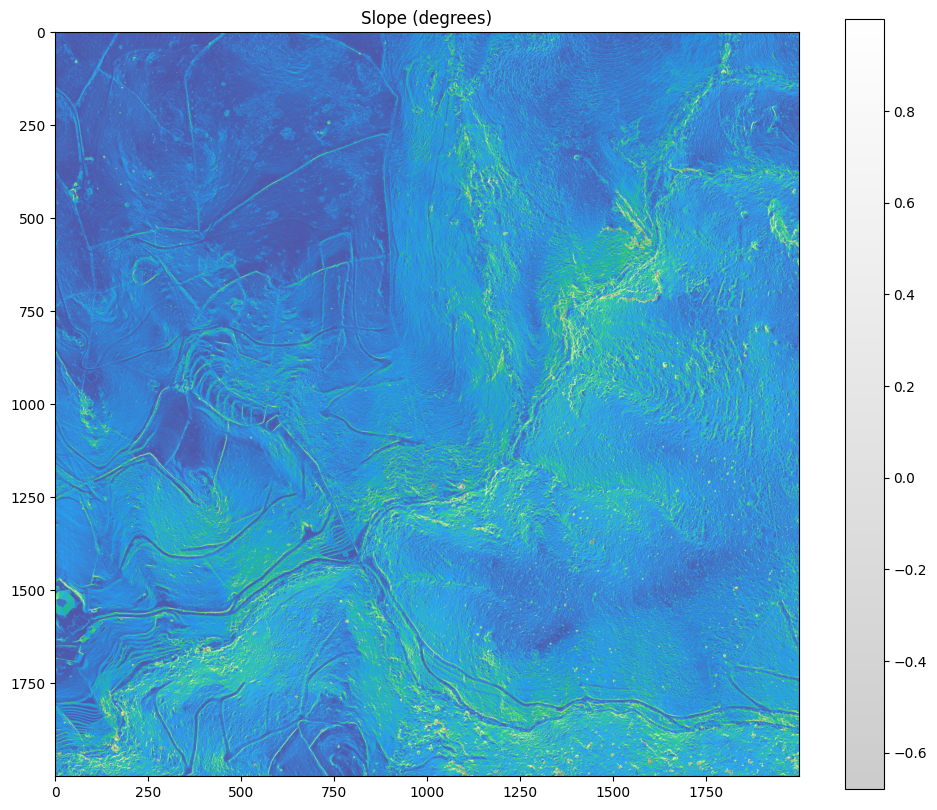

In [ ]:
# Slope e Hilshade plotados juntos
plt.figure(figsize=(12,10))

plt.imshow(slope,cmap="terrain")

plt.imshow(hillshade,cmap="gray",alpha=0.2)

plt.colorbar()
plt.title("Slope (degrees)")
plt.savefig("Slope_Hillshade.png")

plt.show()

In [ ]:
# Curvature - mede como a superficie do terreno muda - positiva: terreno convexo (topos,cristas) negativo: terreno concavo (vales,depressoes), proximas de zero plana

# Primeiras derivadas
dx, dy = np.gradient(dem)

# Segundas derivadas
dxx, dxy = np.gradient(dx)
dyx, dyy = np.gradient(dy)

# Curvatura (Laplaciano)
curvature = dxx + dyy

In [ ]:
# Visualizando
plt.figure(figsize=(12,10))

plt.imshow(
    curvature,
    cmap="RdBu",
    origin="lower"
)

plt.colorbar(label="Curvature")

plt.title("Terrain Curvature")

plt.show()

In [ ]:
# Exportação
with rasterio.open(

"Slope.tif",

"w",

**profile

) as dst:

    dst.write(slope,1)

In [ ]:
# Exportando MDT
# remover NaN
dem_clean = np.nan_to_num(dem, nan=np.nanmin(dem))

# normalizar
dem_min = np.min(dem_clean)
dem_max = np.max(dem_clean)

dem_norm = (dem_clean - dem_min) / (dem_max - dem_min)

# converter pra 16 bits
dem_16 = (dem_norm * 65535).astype(np.uint16)

# salvar
Image.fromarray(dem_16).save("MDT_16bit.png")

In [ ]:
plt.imsave("slope_blender.png", slope, cmap="terrain")
plt.imsave("slope_blender_inf.png", slope, cmap="inferno")